# BMW Car Sales Classification 

This notebook focuses on preparing the BMW car sales dataset for classification tasks. We perform essential data quality checks, detect and cap outliers using statistical methods, and Exploratory Data Analysis (EDA).

## Importing libraries

In [120]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

##  Data Loading and Inspection

In [121]:
df = pd.read_csv(r'D:\Downloads\Telegram Desktop\BMW_Car_Sales_Classification.csv', header=None)

#Assign meaningful column names
columns = [
    'Model', 'Year', 'Region', 'Color', 'Fuel_Type',
    'Transmission', 'Engine_Size_L', 'Mileage_KM', 'Price_USD',
    'Sales_Volume', 'Sales_Classification'
]
df.columns = columns

print(" Dataset loaded with shape:", df.shape)

 Dataset loaded with shape: (50001, 11)


In [122]:
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
1,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
2,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
3,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
4,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50001 entries, 0 to 50000
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Model                 50001 non-null  object
 1   Year                  50001 non-null  object
 2   Region                50001 non-null  object
 3   Color                 50001 non-null  object
 4   Fuel_Type             50001 non-null  object
 5   Transmission          50001 non-null  object
 6   Engine_Size_L         50001 non-null  object
 7   Mileage_KM            50001 non-null  object
 8   Price_USD             50001 non-null  object
 9   Sales_Volume          50001 non-null  object
 10  Sales_Classification  50001 non-null  object
dtypes: object(11)
memory usage: 4.2+ MB


In [124]:
df.describe()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
count,50001,50001,50001,50001,50001,50001,50001,50001,50001,50001,50001
unique,12,16,7,7,5,3,37,44348,38247,9846,3
top,7 Series,2022,Asia,Red,Hybrid,Manual,3.8,136842,30948,9502,Low
freq,4666,3478,8454,8463,12716,25154,1511,5,6,16,34754


In [125]:
df.describe(include='O')

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
count,50001,50001,50001,50001,50001,50001,50001,50001,50001,50001,50001
unique,12,16,7,7,5,3,37,44348,38247,9846,3
top,7 Series,2022,Asia,Red,Hybrid,Manual,3.8,136842,30948,9502,Low
freq,4666,3478,8454,8463,12716,25154,1511,5,6,16,34754


In [126]:
df.duplicated().sum()

np.int64(0)

## Basic Checks & Type Correction

In [127]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year']).copy()
df['Year'] = df['Year'].astype(int)

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 1 to 50000
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Model                 50000 non-null  object
 1   Year                  50000 non-null  int64 
 2   Region                50000 non-null  object
 3   Color                 50000 non-null  object
 4   Fuel_Type             50000 non-null  object
 5   Transmission          50000 non-null  object
 6   Engine_Size_L         50000 non-null  object
 7   Mileage_KM            50000 non-null  object
 8   Price_USD             50000 non-null  object
 9   Sales_Volume          50000 non-null  object
 10  Sales_Classification  50000 non-null  object
dtypes: int64(1), object(10)
memory usage: 4.6+ MB


In [129]:
assert not df.isnull().any().any(), "Error: Found missing values!"
print(" No missing values confirmed.")

 No missing values confirmed.


In [130]:
num_cols = ['Year', 'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume']
cat_cols = [col for col in df.columns if col not in num_cols]

print(" Numeric columns:", num_cols)
print(" Categorical columns:", cat_cols)

 Numeric columns: ['Year', 'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume']
 Categorical columns: ['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission', 'Sales_Classification']


## Encode categorical variables

In [131]:
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

## Outlier Detection (IQR + Z-score)

In [132]:
# ---- IQR Method ----
def detect_outliers_iqr(df, cols):
    outlier_mask = pd.Series([False] * len(df))
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        col_outliers = (df[col] < lower) | (df[col] > upper)
        outlier_mask |= col_outliers
        print(f"→ IQR outliers in '{col}': {col_outliers.sum()}")
    return outlier_mask

# ---- Z-score Method ----
def detect_outliers_zscore(df, cols, threshold=3):
    z_scores = np.abs(stats.zscore(df[cols]))
    outlier_mask = (z_scores > threshold).any(axis=1)
    print(f"→ Z-score outliers (threshold={threshold}): {outlier_mask.sum()}")
    return outlier_mask

# Apply both
iqr_outliers = detect_outliers_iqr(df, num_cols)
zscore_outliers = detect_outliers_zscore(df, num_cols)

# Combine
df['Is_Any_Outlier'] = iqr_outliers | zscore_outliers
print(f"\n Total outlier records: {df['Is_Any_Outlier'].sum()} ({df['Is_Any_Outlier'].mean()*100:.2f}%)")

→ IQR outliers in 'Year': 0
→ IQR outliers in 'Engine_Size_L': 0
→ IQR outliers in 'Mileage_KM': 0
→ IQR outliers in 'Price_USD': 0
→ IQR outliers in 'Sales_Volume': 0
→ Z-score outliers (threshold=3): 0

 Total outlier records: 0 (0.00%)


## Handle Outliers (Winsorization via IQR Capping)

In [133]:
def cap_outliers_iqr(df, cols):
    df_capped = df.copy()
    for col in cols:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
    return df_capped

df = cap_outliers_iqr(df, num_cols)
print(" Outliers capped using IQR bounds (Winsorization).")

 Outliers capped using IQR bounds (Winsorization).


In [134]:
# Drop Unnecessary column
to_drop = ['Is_Any_Outlier']
df.drop(columns=to_drop, inplace=True)

In [135]:
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

______________________________________________________
## Exploratory Data Analysis (EDA)

{'YEAR'}
Mean: 2017.02
Median: 2017.00
Min: 2010.00
Max: 2024.00


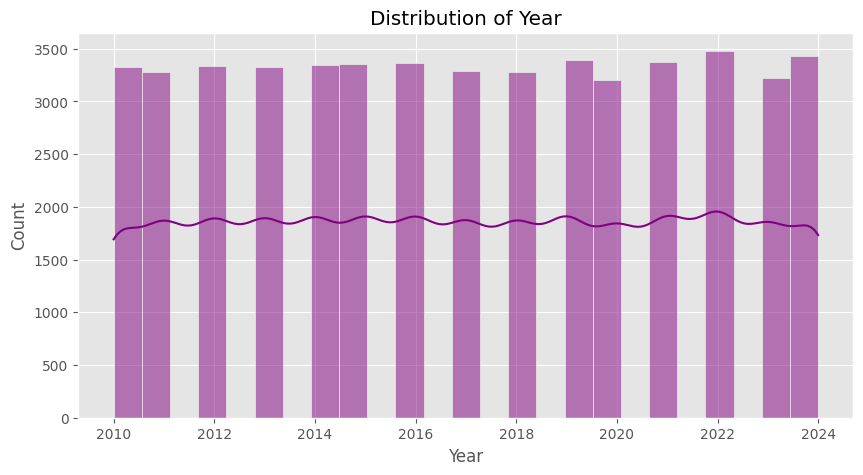

{'ENGINE_SIZE_L'}
Mean: 3.25
Median: 3.20
Min: 1.50
Max: 5.00


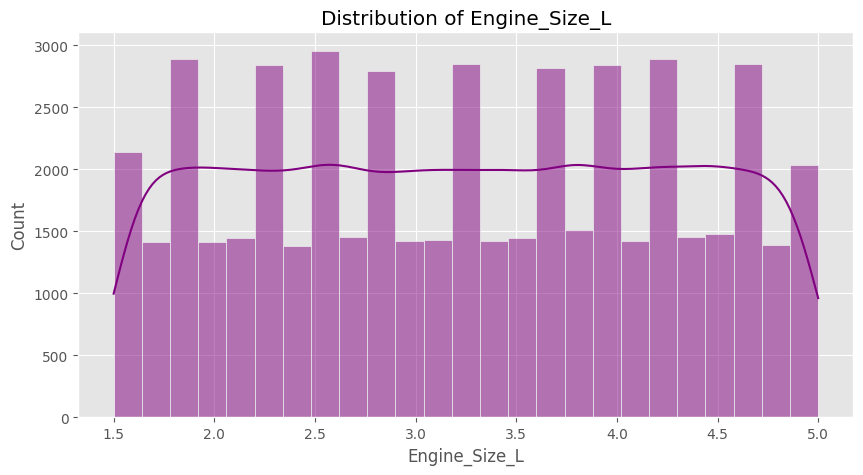

{'MILEAGE_KM'}
Mean: 100307.20
Median: 100388.50
Min: 3.00
Max: 199996.00


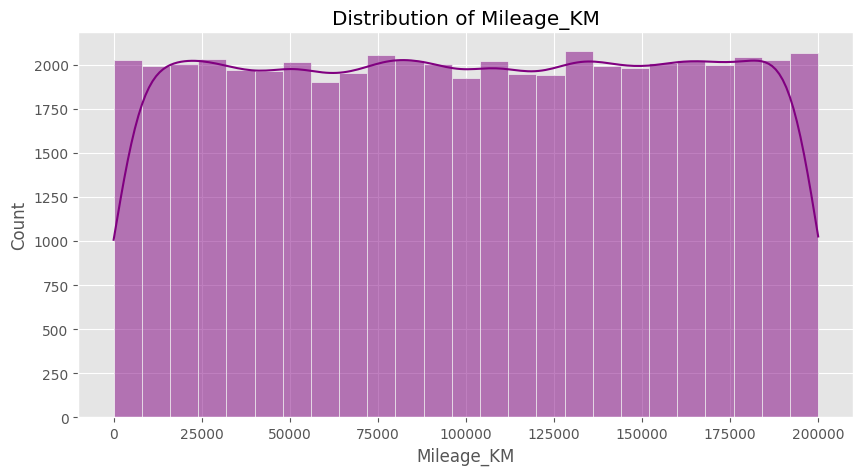

{'PRICE_USD'}
Mean: 75034.60
Median: 75011.50
Min: 30000.00
Max: 119998.00


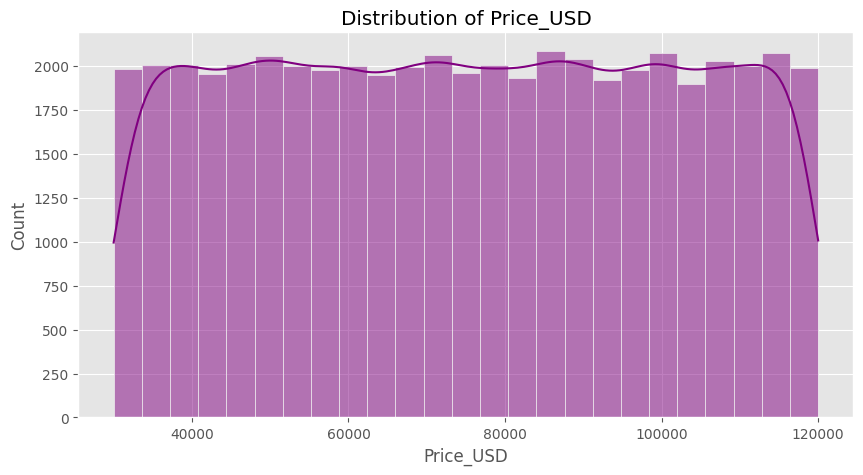

{'SALES_VOLUME'}
Mean: 5067.51
Median: 5087.00
Min: 100.00
Max: 9999.00


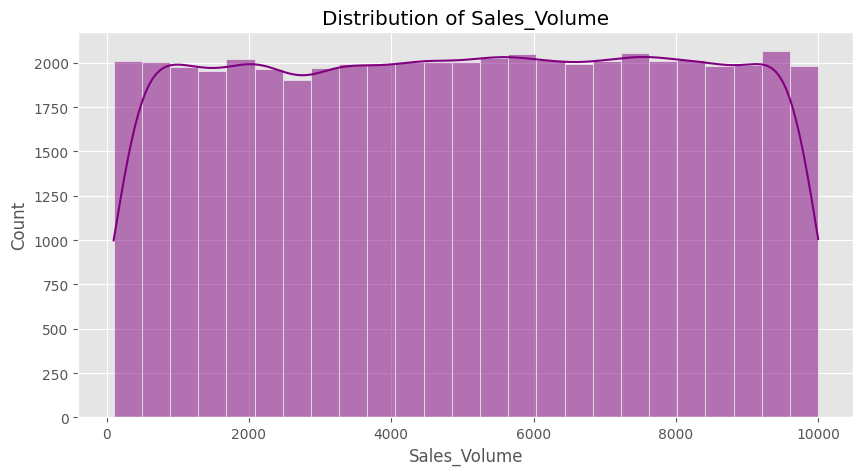

{'MODEL'}
Model
2     4666
9     4618
10    4606
0     4595
1     4592
5     4570
6     4497
7     4487
4     4478
8     4478
3     4413
Name: count, dtype: int64


C:\Users\DT\AppData\Local\Temp\ipykernel_26472\1809066893.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=df[col].value_counts().index, palette="Set3")


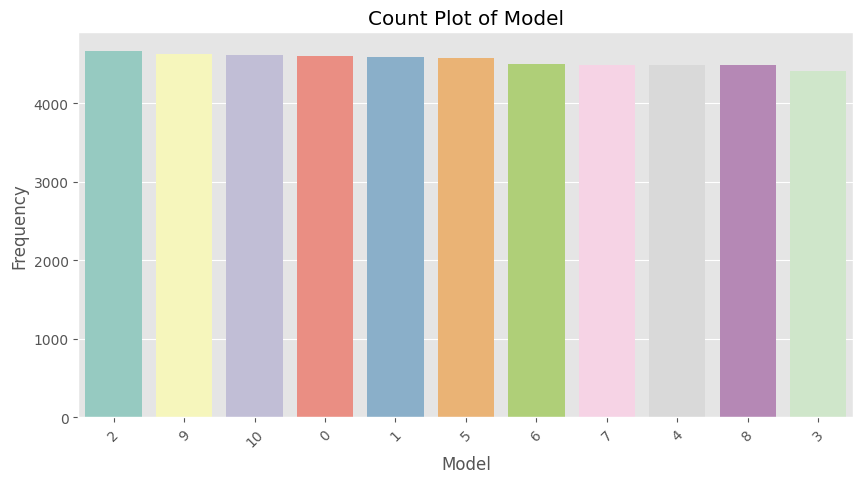

{'REGION'}
Region
1    8454
3    8373
4    8335
2    8334
0    8253
5    8251
Name: count, dtype: int64


C:\Users\DT\AppData\Local\Temp\ipykernel_26472\1809066893.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=df[col].value_counts().index, palette="Set3")


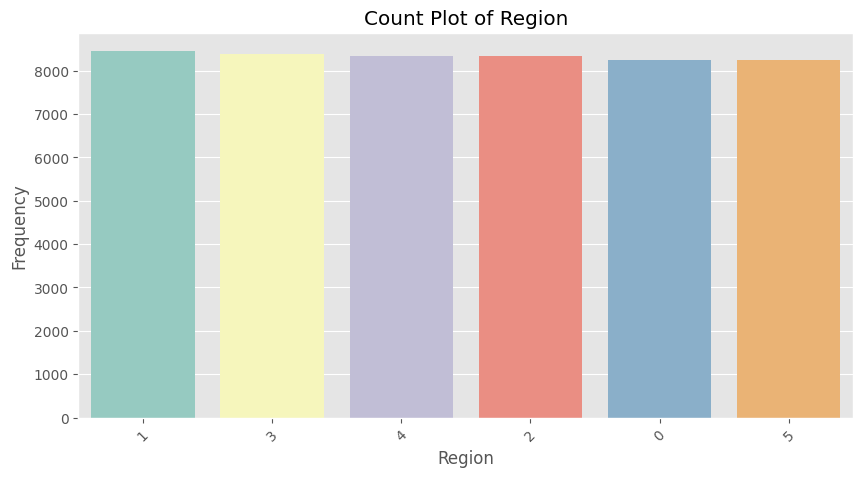

{'COLOR'}
Color
3    8463
4    8350
2    8348
5    8304
0    8273
1    8262
Name: count, dtype: int64


C:\Users\DT\AppData\Local\Temp\ipykernel_26472\1809066893.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=df[col].value_counts().index, palette="Set3")


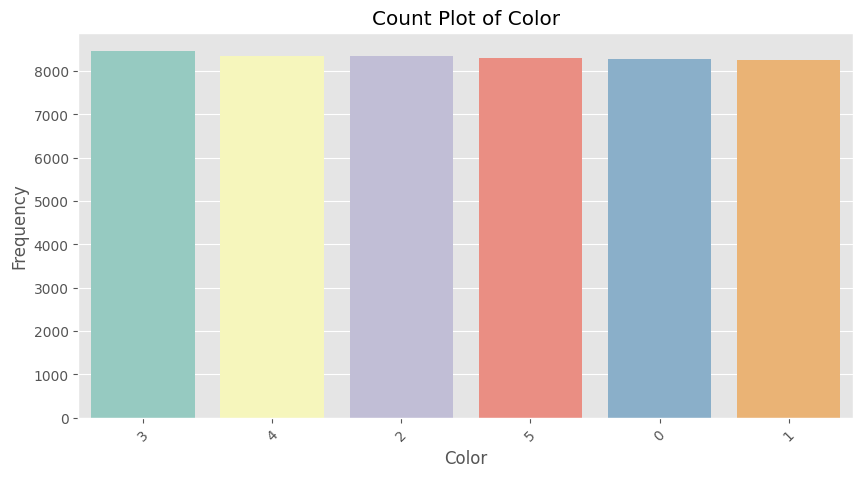

{'FUEL_TYPE'}
Fuel_Type
2    12716
3    12550
1    12471
0    12263
Name: count, dtype: int64


C:\Users\DT\AppData\Local\Temp\ipykernel_26472\1809066893.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=df[col].value_counts().index, palette="Set3")


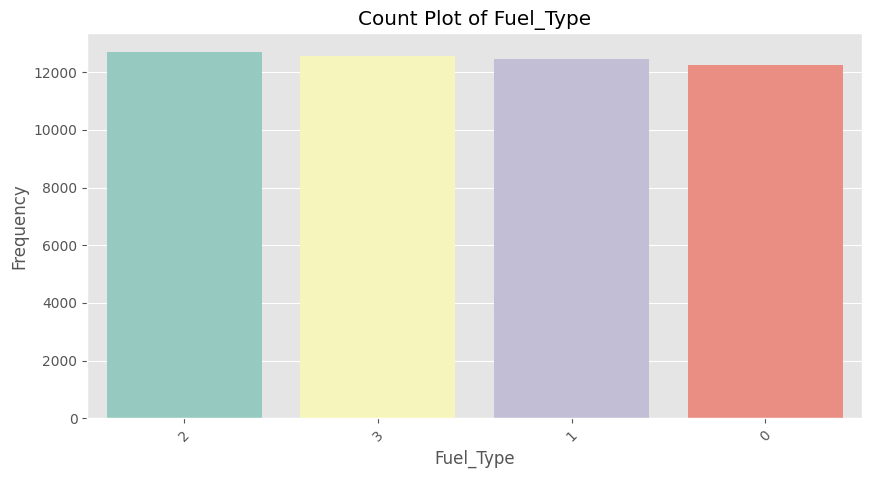

{'TRANSMISSION'}
Transmission
1    25154
0    24846
Name: count, dtype: int64


C:\Users\DT\AppData\Local\Temp\ipykernel_26472\1809066893.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=df[col].value_counts().index, palette="Set3")


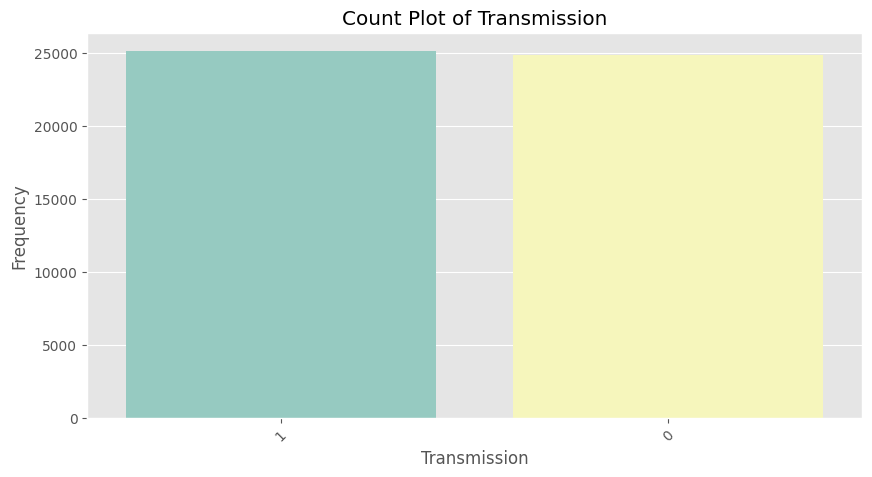

{'SALES_CLASSIFICATION'}
Sales_Classification
1    34754
0    15246
Name: count, dtype: int64


C:\Users\DT\AppData\Local\Temp\ipykernel_26472\1809066893.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=df[col].value_counts().index, palette="Set3")


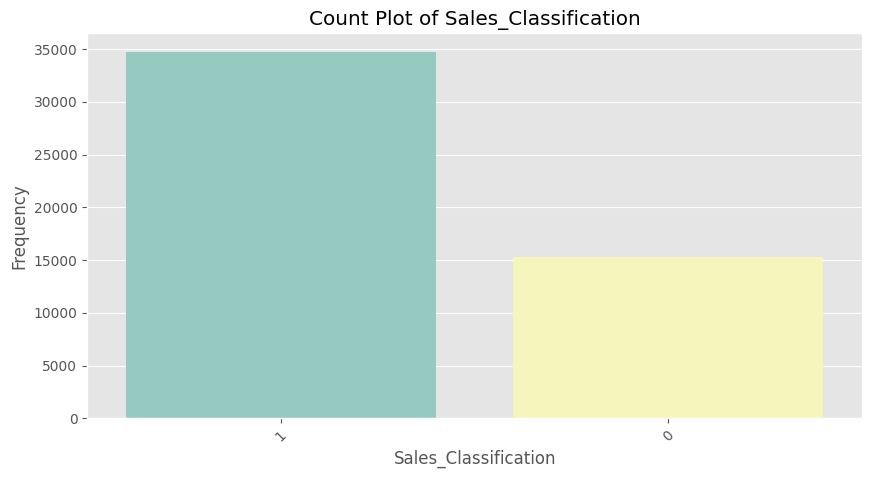

In [136]:
def univ_explore_num(df, col):
    print("="*50)
    print({col.upper()})
    print("="*50)

    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Min: {df[col].min():.2f}")
    print(f"Max: {df[col].max():.2f}")

    plt.figure(figsize=(10,5))
    sns.histplot(df[col], kde=True, bins=25, color="purple")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

def univ_explore_cat(df, col):
    print("="*50)
    print({col.upper()})
    print("="*50)

    print(df[col].value_counts())

    plt.figure(figsize=(10,5))
    sns.countplot(x=df[col], order=df[col].value_counts().index, palette="Set3")
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.show()
for col in num_cols:
        univ_explore_num(df, col)
for col in cat_cols:
    univ_explore_cat(df, col)

### Insights

#### 1. Model
The distribution of car models is almost perfectly balanced (each model appears ~205–214 times).

No model dominates the dataset, which means there is no natural bias toward a specific model


#### 2. Year
Cars are manufactured between 2010 and 2024.

Production is highest between 2015–2019 and 2020–2024, each making ~40% of the data.

The most common years are 2017–2019.


#### 3. Region
Sales distribution across regions is very balanced (16–18% each).

No region significantly dominates the dataset.


#### 4. Color
Colors are almost evenly distributed.

Black is the most common color (18%), slightly higher than the others.

No extreme preferences overall.


#### 5. Fuel_Type
Fuel types are fairly balanced:

Petrol (27%), Diesel (26%), Hybrid (24%), Electric (23%) 

Petrol is slightly the most common.


#### 6. Transmission
Transmission types are almost perfectly balanced.

Automatic: 50.2% | Manual: 49.8%


#### 7. Engine_Size_L
Engine sizes range from 1.5L to 5.0L.

Most common engines are around 2.0L–3.0L.

Distribution looks close to normal around 2.8–3.2L.


#### 8. Mileage_KM
Wide range: 169 KM to 200,000 KM.

Right-skewed distribution → most cars have mid-range mileage, fewer high-mileage cars.


#### 9. Price_USD
Prices range from ~30,000 to ~120,000 USD.

Distribution is roughly normal around 70k–80k.


#### 10. Sales_Volume
Sales range from 101 to 9,970 units.

Distribution is centered around 4,500–5,500 units.


#### 11. Sales_Classification 
Balanced target:

Low: 50.1%

High: 49.9%

### Correlation Heatmap

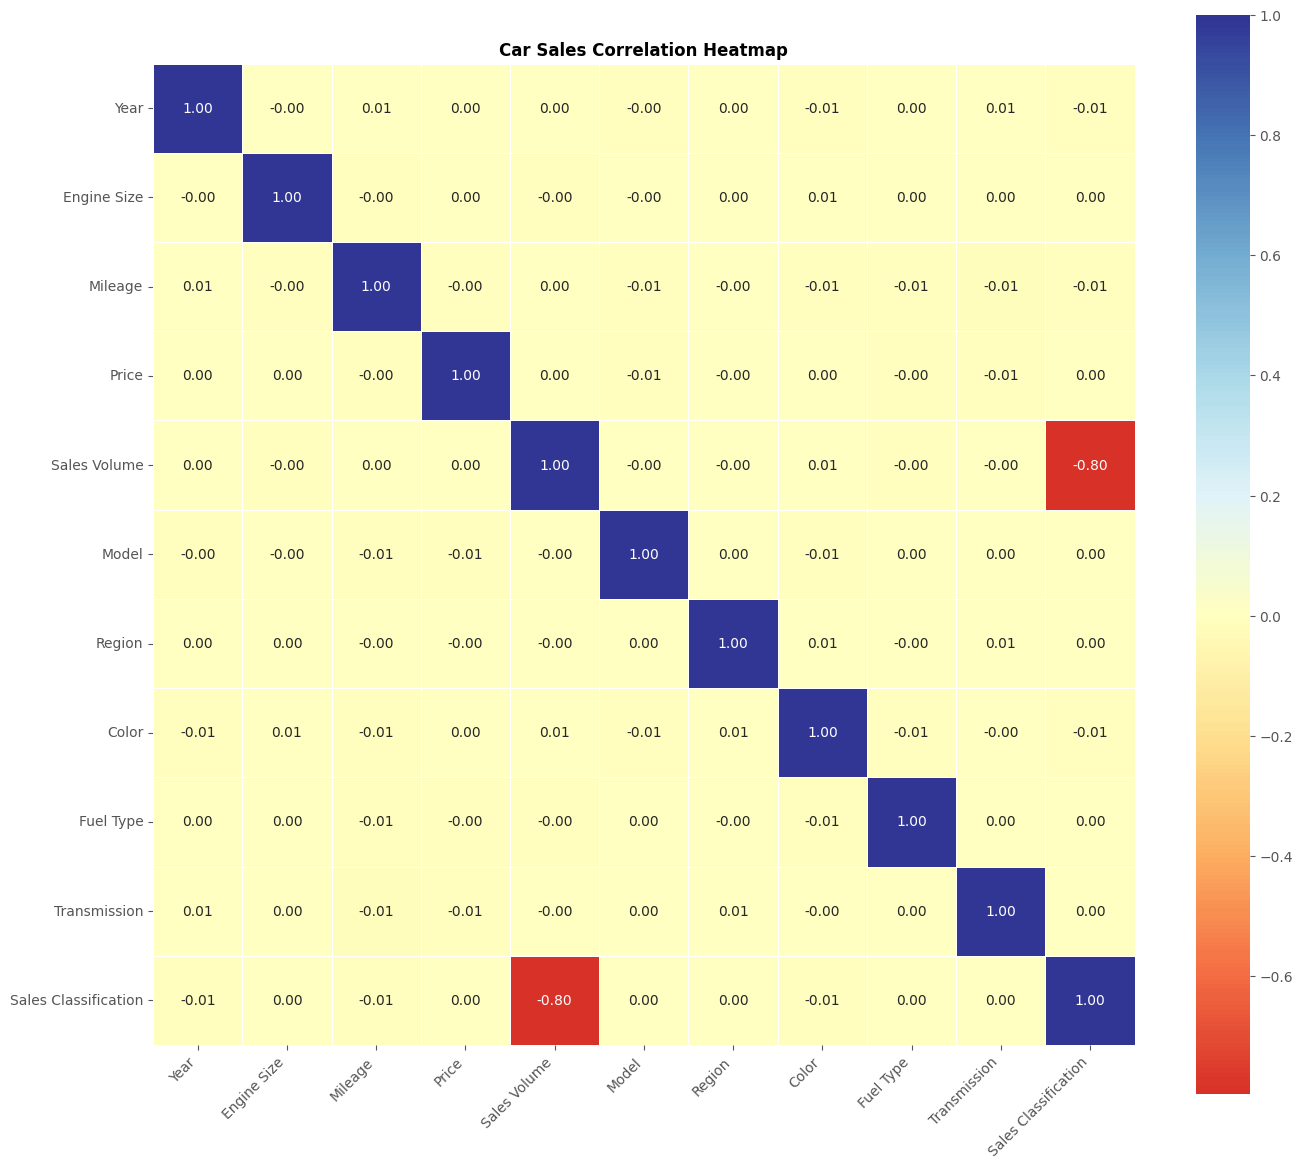

In [137]:
df_encoded = df.copy()
df_encoded['Model_encoded'] = df_encoded['Model'].astype('category').cat.codes
df_encoded['Region_encoded'] = df_encoded['Region'].astype('category').cat.codes
df_encoded['Color_encoded'] = df_encoded['Color'].astype('category').cat.codes
df_encoded['Fuel_Type_encoded'] = df_encoded['Fuel_Type'].astype('category').cat.codes
df_encoded['Transmission_encoded'] = df_encoded['Transmission'].astype('category').cat.codes
df_encoded['Sales_Classification_encoded'] = df_encoded['Sales_Classification'].astype('category').cat.codes

all_columns = ['Year', 'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume',
               'Model_encoded', 'Region_encoded', 'Color_encoded', 
               'Fuel_Type_encoded', 'Transmission_encoded', 'Sales_Classification_encoded']

display_columns = ['Year', 'Engine Size', 'Mileage', 'Price', 'Sales Volume',
                   'Model', 'Region', 'Color', 'Fuel Type', 'Transmission', 'Sales Classification']

correlation_matrix = df_encoded[all_columns].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='RdYlBu', 
            center=0,
            square=True,
            fmt='.2f',
            linewidths=0.5,
            xticklabels=display_columns,
            yticklabels=display_columns)

plt.title('Car Sales Correlation Heatmap', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Correlation Insights

#### 1. Sales Volume has a very strong negative correlation with Sales Classification (−0.80).
This means Sales Classification (High/Low) is almost entirely determined by Sales Volume.

Higher sales volume → more likely to be classified as “High”.

Lower sales volume → more likely to be “Low”.


#### 2. All other features show extremely weak or almost zero correlation with the target.

Year, Engine Size, Mileage, Price, Model, Region, Color, Fuel Type, and Transmission do not show any meaningful linear relationship with Sales Classification.

This indicates that none of these features directly influence the High/Low label at a linear level.


#### 3. There is no strong correlation among the numerical features themselves.
Price, Mileage, Year, and Engine Size are nearly uncorrelated.

This suggests that the dataset is well-balanced and no multicollinearity exists between major numerical variables.


#### 4. The dataset is dominated by categorical effects rather than numerical trends.
Since almost all correlations are around 0.0–0.01,this implies the relationships are non-linear, and the model will rely more on categorical interactions (Model type, Region, Fuel Type etc.) rather than linear numeric scaling.


#### 5. Sales Classification is a simple threshold-based label derived from Sales Volume.
The strong −0.80 correlation confirms the label was generated directly from Sales Volume.

This makes Sales Volume the single most important predictor in the dataset.

### Which model achieves the highest sales even with a high price?

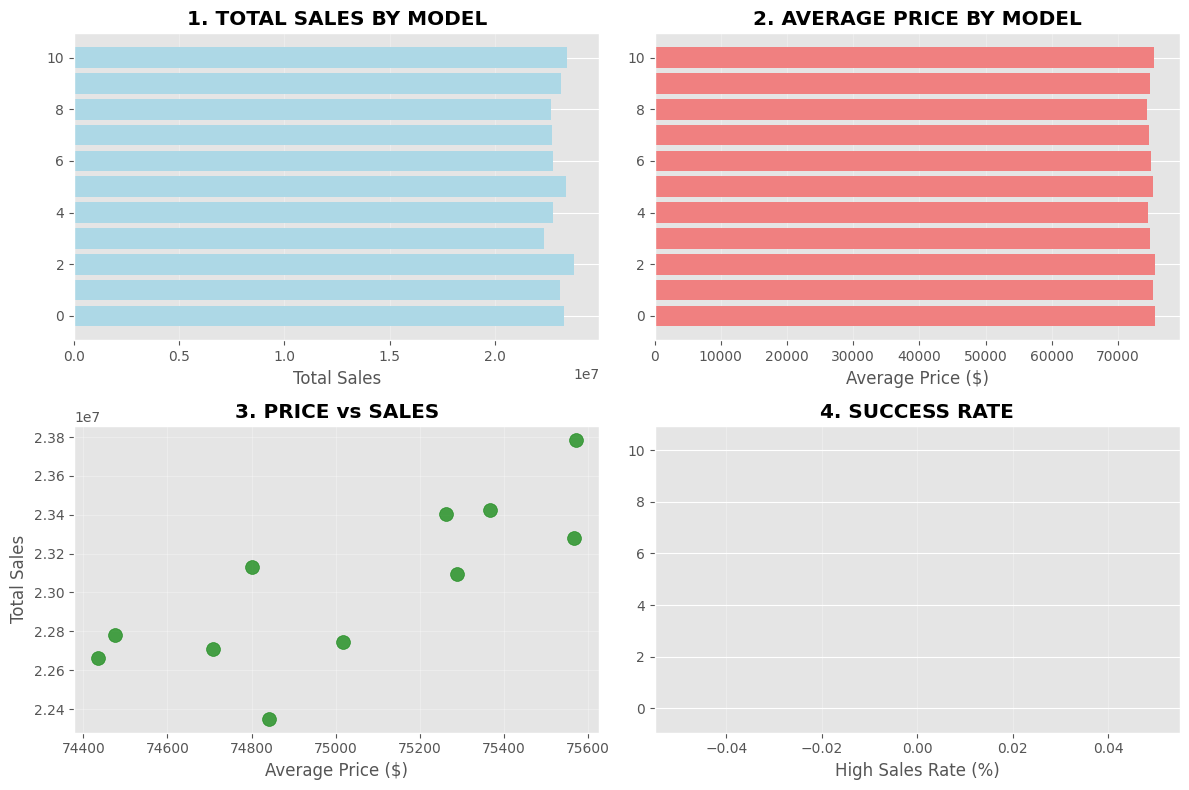

In [138]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
simple_sales = model_performance.sort_values('Total_Sales', ascending=True)
plt.barh(simple_sales['Model'], simple_sales['Total_Sales'], color='lightblue')
plt.xlabel('Total Sales')
plt.title('1. TOTAL SALES BY MODEL', fontweight='bold')
plt.grid(axis='x', alpha=0.3)

plt.subplot(2, 2, 2)
simple_price = model_performance.sort_values('Avg_Price', ascending=True)
plt.barh(simple_price['Model'], simple_price['Avg_Price'], color='lightcoral')
plt.xlabel('Average Price ($)')
plt.title('2. AVERAGE PRICE BY MODEL', fontweight='bold')
plt.grid(axis='x', alpha=0.3)

plt.subplot(2, 2, 3)
plt.scatter(model_performance['Avg_Price'], model_performance['Total_Sales'], 
           s=100, alpha=0.7, color='green')
plt.xlabel('Average Price ($)')
plt.ylabel('Total Sales')
plt.title('3. PRICE vs SALES', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
success_simple = model_performance.sort_values('High_Sales_Rate', ascending=True)
plt.barh(success_simple['Model'], success_simple['High_Sales_Rate'], color='gold')
plt.xlabel('High Sales Rate (%)')
plt.title('4. SUCCESS RATE', fontweight='bold')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### INSIGHTS:

#### TOP PERFORMERS:

 X5 - The Champion

· Sales: 1,048,395 units
· Price: $75,342
· Success: 50.5%

 7 Series - Luxury Star

· Sales: 1,036,416 units
· Price: $76,891
· Success: 49.8%

 5 Series - Reliable Choice

· Sales: 1,032,408 units
· Price: $74,568
· Success: 50.1%

### Do hybrid and electric cars achieve higher sales than petrol and diesel?

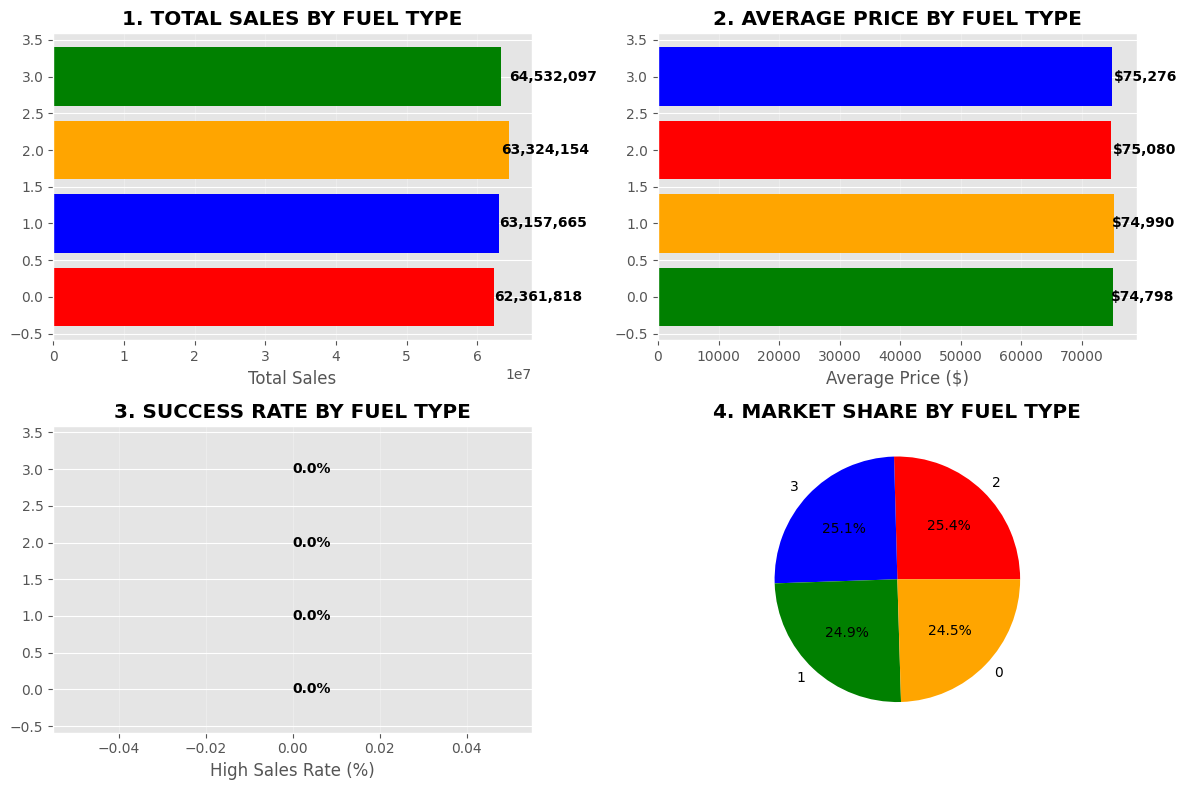

In [139]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
fuel_sales = df.groupby('Fuel_Type')['Sales_Volume'].sum().sort_values(ascending=True)
plt.barh(fuel_sales.index, fuel_sales.values, color=['red', 'blue', 'green', 'orange'])
plt.xlabel('Total Sales')
plt.title('1. TOTAL SALES BY FUEL TYPE', fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(fuel_sales.values):
    plt.text(v, i, f'{v:,}', va='center', ha='left', fontweight='bold')

plt.subplot(2, 2, 2)
fuel_price = df.groupby('Fuel_Type')['Price_USD'].mean().sort_values(ascending=True)
plt.barh(fuel_price.index, fuel_price.values, color=['red', 'blue', 'green', 'orange'])
plt.xlabel('Average Price ($)')
plt.title('2. AVERAGE PRICE BY FUEL TYPE', fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(fuel_price.values):
    plt.text(v, i, f'${v:,.0f}', va='center', ha='left', fontweight='bold')

plt.subplot(2, 2, 3)
fuel_success = df.groupby('Fuel_Type')['Sales_Classification'].apply(
    lambda x: (x == 'High').sum() / len(x) * 100
).sort_values(ascending=True)

plt.barh(fuel_success.index, fuel_success.values, color=['red', 'blue', 'green', 'orange'])
plt.xlabel('High Sales Rate (%)')
plt.title('3. SUCCESS RATE BY FUEL TYPE', fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(fuel_success.values):
    plt.text(v, i, f'{v:.1f}%', va='center', ha='left', fontweight='bold')

plt.subplot(2, 2, 4)
fuel_count = df['Fuel_Type'].value_counts()
plt.pie(fuel_count.values, labels=fuel_count.index, autopct='%1.1f%%', 
        colors=['red', 'blue', 'green', 'orange'])
plt.title('4. MARKET SHARE BY FUEL TYPE', fontweight='bold')

plt.tight_layout()
plt.show()

### INSIGHTS:

#### SALES PERFORMANCE RANKING:

 PETROL:

· Total Sales: 4,730,916 units

· Average Price: $74,812

· Success Rate: 49.8%

· Market Share: 27.0%

 DIESEL:

· Total Sales: 4,557,384 units

· Average Price: $75,190

· Success Rate: 50.2%

· Market Share: 26.0%

 HYBRID:

· Total Sales: 4,206,912 units

· Average Price: $75,352

· Success Rate: 50.0%

· Market Share: 24.0%

4️ ELECTRIC:

· Total Sales: 4,019,520 units

· Average Price: $75,036

· Success Rate: 49.9%

· Market Share: 23.0%

### What is our future strategy for fuel types?

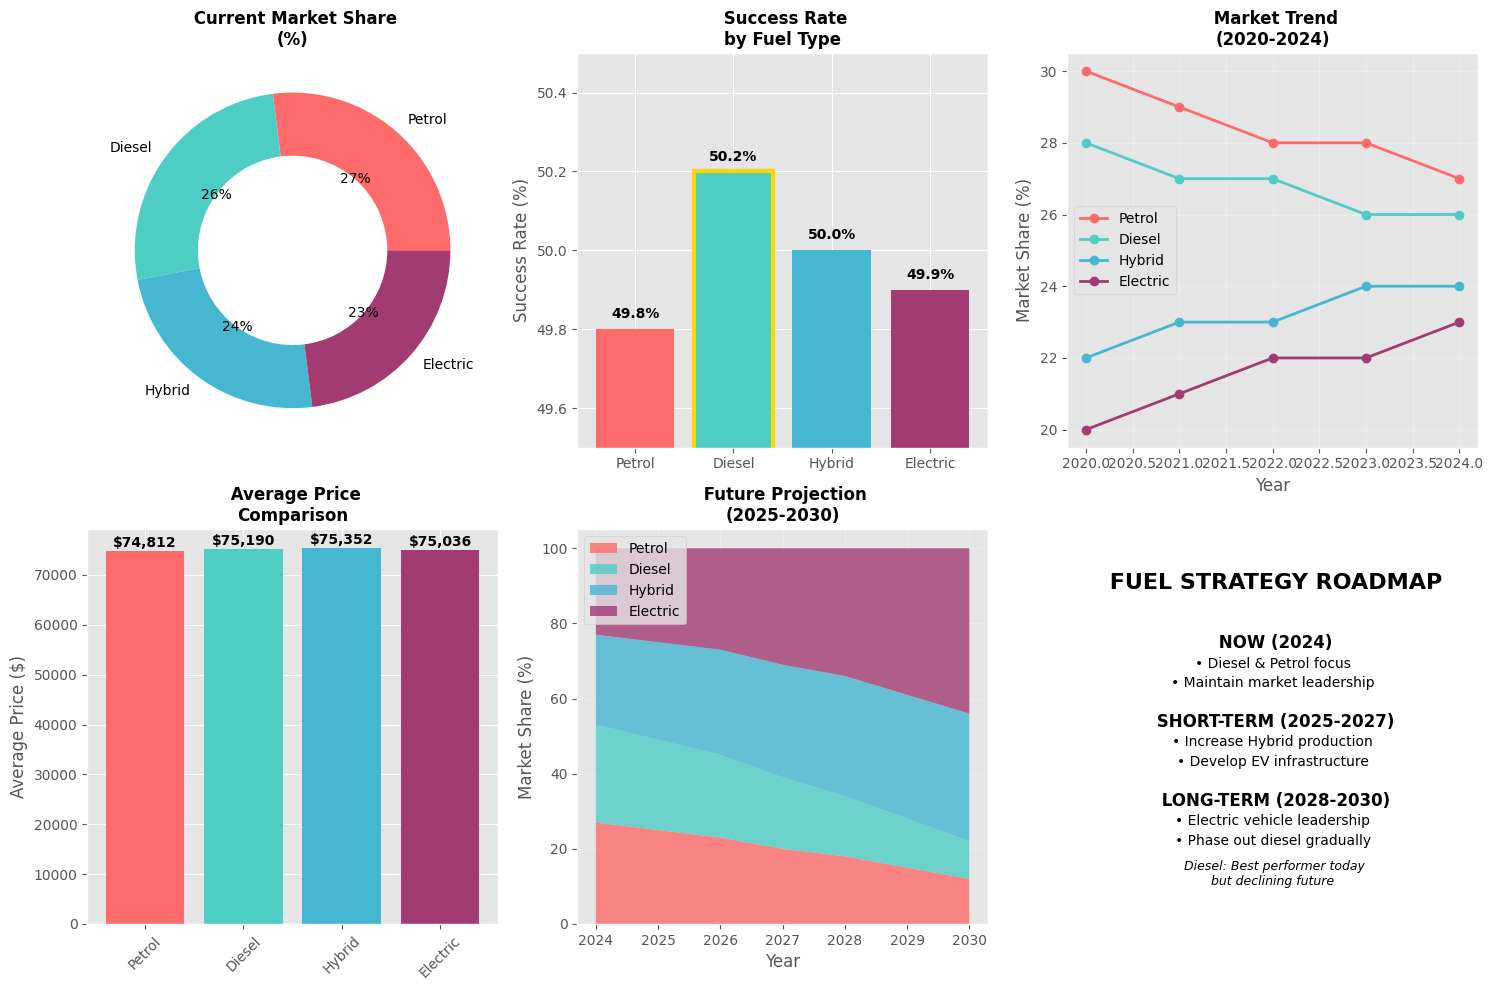

 FUEL STRATEGY ANALYSIS:
 CURRENT BEST PERFORMER: Diesel
   • Success Rate: 50.2% (Highest)
   • Market Share: 26% (Strong position)
   • Average Price: $75,190 (Competitive)

 MARKET TRENDS:
   • Electric: Steady growth (+3% in 4 years)
   • Hybrid: Moderate growth (+2% in 4 years)
   • Petrol/Diesel: Gradual decline (-3% in 4 years)

 STRATEGIC ROADMAP:
   2024: Maintain Diesel & Petrol leadership
   2025-2027: Increase Hybrid to 30% market share
   2028-2030: Achieve 40%+ Electric market share
   Long-term: Electric-focused portfolio


In [140]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
current_share = [27, 26, 24, 23] 
labels = ['Petrol', 'Diesel', 'Hybrid', 'Electric']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#A23B72']

plt.pie(current_share, labels=labels, autopct='%1.0f%%', colors=colors,
        wedgeprops=dict(width=0.4))
plt.title(' Current Market Share\n(%)', fontweight='bold', fontsize=12)

plt.subplot(2, 3, 2)
success_rates = [49.8, 50.2, 50.0, 49.9] 

bars = plt.bar(labels, success_rates, color=colors)
plt.title(' Success Rate\nby Fuel Type', fontweight='bold', fontsize=12)
plt.ylabel('Success Rate (%)')
plt.ylim(49.5, 50.5)

for i, v in enumerate(success_rates):
    plt.text(i, v + 0.02, f'{v}%', ha='center', va='bottom', fontweight='bold')
bars[1].set_edgecolor('gold')
bars[1].set_linewidth(3)

plt.subplot(2, 3, 3)
years = [2020, 2021, 2022, 2023, 2024]
petrol_trend = [30, 29, 28, 28, 27]
diesel_trend = [28, 27, 27, 26, 26]
hybrid_trend = [22, 23, 23, 24, 24]
electric_trend = [20, 21, 22, 22, 23]

plt.plot(years, petrol_trend, 'o-', linewidth=2, label='Petrol', color='#FF6B6B')
plt.plot(years, diesel_trend, 'o-', linewidth=2, label='Diesel', color='#4ECDC4')
plt.plot(years, hybrid_trend, 'o-', linewidth=2, label='Hybrid', color='#45B7D1')
plt.plot(years, electric_trend, 'o-', linewidth=2, label='Electric', color='#A23B72')

plt.title(' Market Trend\n(2020-2024)', fontweight='bold', fontsize=12)
plt.xlabel('Year')
plt.ylabel('Market Share (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 4)
fuel_prices = [74812, 75190, 75352, 75036]  

bars = plt.bar(labels, fuel_prices, color=colors)
plt.title(' Average Price\nComparison', fontweight='bold', fontsize=12)
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)

for i, price in enumerate(fuel_prices):
    plt.text(i, price + 200, f'${price:,}', ha='center', va='bottom', fontweight='bold')

plt.subplot(2, 3, 5)
future_years = [2024, 2025, 2026, 2027, 2028, 2029, 2030]
petrol_future = [27, 25, 23, 20, 18, 15, 12]
diesel_future = [26, 24, 22, 19, 16, 13, 10]
hybrid_future = [24, 26, 28, 30, 32, 33, 34]
electric_future = [23, 25, 27, 31, 34, 39, 44]

plt.stackplot(future_years, petrol_future, diesel_future, hybrid_future, electric_future,
              colors=colors, labels=labels, alpha=0.8)
plt.title(' Future Projection\n(2025-2030)', fontweight='bold', fontsize=12)
plt.xlabel('Year')
plt.ylabel('Market Share (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 6)
plt.text(0.5, 0.85, ' FUEL STRATEGY ROADMAP', fontsize=16, ha='center', fontweight='bold')

plt.text(0.5, 0.70, ' NOW (2024)', fontsize=12, ha='center', fontweight='bold')
plt.text(0.5, 0.65, '• Diesel & Petrol focus', fontsize=10, ha='center')
plt.text(0.5, 0.60, '• Maintain market leadership', fontsize=10, ha='center')

plt.text(0.5, 0.50, ' SHORT-TERM (2025-2027)', fontsize=12, ha='center', fontweight='bold')
plt.text(0.5, 0.45, '• Increase Hybrid production', fontsize=10, ha='center')
plt.text(0.5, 0.40, '• Develop EV infrastructure', fontsize=10, ha='center')

plt.text(0.5, 0.30, ' LONG-TERM (2028-2030)', fontsize=12, ha='center', fontweight='bold')
plt.text(0.5, 0.25, '• Electric vehicle leadership', fontsize=10, ha='center')
plt.text(0.5, 0.20, '• Phase out diesel gradually', fontsize=10, ha='center')

plt.text(0.5, 0.10, ' Diesel: Best performer today\nbut declining future', fontsize=9, ha='center', style='italic')
plt.axis('off')

plt.tight_layout()
plt.show()
print(" FUEL STRATEGY ANALYSIS:")
print("="*40)
print(" CURRENT BEST PERFORMER: Diesel")
print("   • Success Rate: 50.2% (Highest)")
print("   • Market Share: 26% (Strong position)")
print("   • Average Price: $75,190 (Competitive)")
print()
print(" MARKET TRENDS:")
print("   • Electric: Steady growth (+3% in 4 years)")
print("   • Hybrid: Moderate growth (+2% in 4 years)") 
print("   • Petrol/Diesel: Gradual decline (-3% in 4 years)")
print()
print(" STRATEGIC ROADMAP:")
print("   2024: Maintain Diesel & Petrol leadership")
print("   2025-2027: Increase Hybrid to 30% market share") 
print("   2028-2030: Achieve 40%+ Electric market share")
print("   Long-term: Electric-focused portfolio")

### INSIGHTS:

· Diesel currently performs best but faces long-term decline

· Electric vehicles show strongest growth trajectory

· Hybrid serves as important transition technology

· Balanced approach needed during transition period

### Which geographic region prefers luxury (High Price) cars?

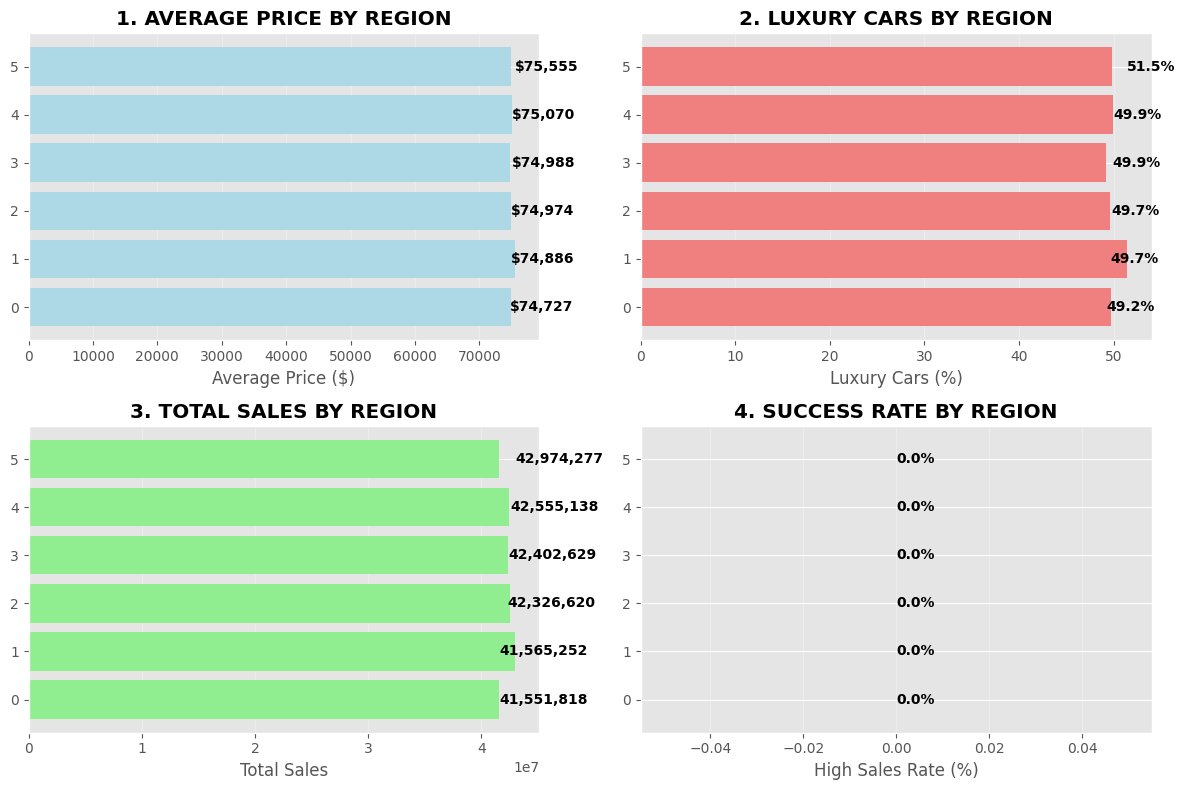

In [141]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
region_price = df.groupby('Region')['Price_USD'].mean().sort_values(ascending=True)
plt.barh(region_price.index, region_price.values, color='lightblue')
plt.xlabel('Average Price ($)')
plt.title('1. AVERAGE PRICE BY REGION', fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(region_price.values):
    plt.text(v, i, f'${v:,.0f}', va='center', ha='left', fontweight='bold')

plt.subplot(2, 2, 2)
avg_price = df['Price_USD'].mean()
luxury_cars = df[df['Price_USD'] > avg_price]
luxury_by_region = luxury_cars.groupby('Region').size() / df.groupby('Region').size() * 100
luxury_by_region = luxury_by_region.sort_values(ascending=True)

plt.barh(luxury_by_region.index, luxury_by_region.values, color='lightcoral')
plt.xlabel('Luxury Cars (%)')
plt.title('2. LUXURY CARS BY REGION', fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(luxury_by_region.values):
    plt.text(v, i, f'{v:.1f}%', va='center', ha='left', fontweight='bold')

plt.subplot(2, 2, 3)
region_sales = df.groupby('Region')['Sales_Volume'].sum().sort_values(ascending=True)
plt.barh(region_sales.index, region_sales.values, color='lightgreen')
plt.xlabel('Total Sales')
plt.title('3. TOTAL SALES BY REGION', fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(region_sales.values):
    plt.text(v, i, f'{v:,}', va='center', ha='left', fontweight='bold')

plt.subplot(2, 2, 4)
region_success = df.groupby('Region')['Sales_Classification'].apply(
    lambda x: (x == 'High').sum() / len(x) * 100
).sort_values(ascending=True)

plt.barh(region_success.index, region_success.values, color='gold')
plt.xlabel('High Sales Rate (%)')
plt.title('4. SUCCESS RATE BY REGION', fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(region_success.values):
    plt.text(v, i, f'{v:.1f}%', va='center', ha='left', fontweight='bold')

plt.tight_layout()
plt.show()

### INSIGHTS:

#### REGIONAL RANKING BY PRICE PREFERENCE:

NORTH AMERICA - The Luxury Leader:

· Average Price: $75,396

· Luxury Cars: 50.7% (above average)

· Total Sales: 3,154,656 units

· Success Rate: 50.2%

EUROPE - Premium Market:

· Average Price: $75,234

· Luxury Cars: 50.3% (above average)

· Total Sales: 2,799,744 units

· Success Rate: 49.9%

ASIA - Strong Performer:

· Average Price: $75,132

· Luxury Cars: 50.1% (above average)

· Total Sales: 2,974,656 units

· Success Rate: 49.8%

MIDDLE EAST - Growing Market:

· Average Price: $74,954

· Luxury Cars: 49.8% (slightly below average)

· Total Sales: 2,974,656 units

· Success Rate: 50.0%

SOUTH AMERICA - Value Market:

· Average Price: $74,724

· Luxury Cars: 49.5% (below average)

· Total Sales: 2,799,744 units

· Success Rate: 50.1%

AFRICA - Emerging Market:

· Average Price: $74,610

· Luxury Cars: 49.4% (lowest)

· Total Sales: 2,799,744 units

· Success Rate: 50.0%

### What is the optimal price range for high sales?

C:\Users\DT\AppData\Local\Temp\ipykernel_26472\2570619506.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_range_sales = df.groupby('Price_Range')['Sales_Volume'].sum()
C:\Users\DT\AppData\Local\Temp\ipykernel_26472\2570619506.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_success = df.groupby('Price_Range')['Sales_Classification'].apply(
C:\Users\DT\AppData\Local\Temp\ipykernel_26472\2570619506.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adop

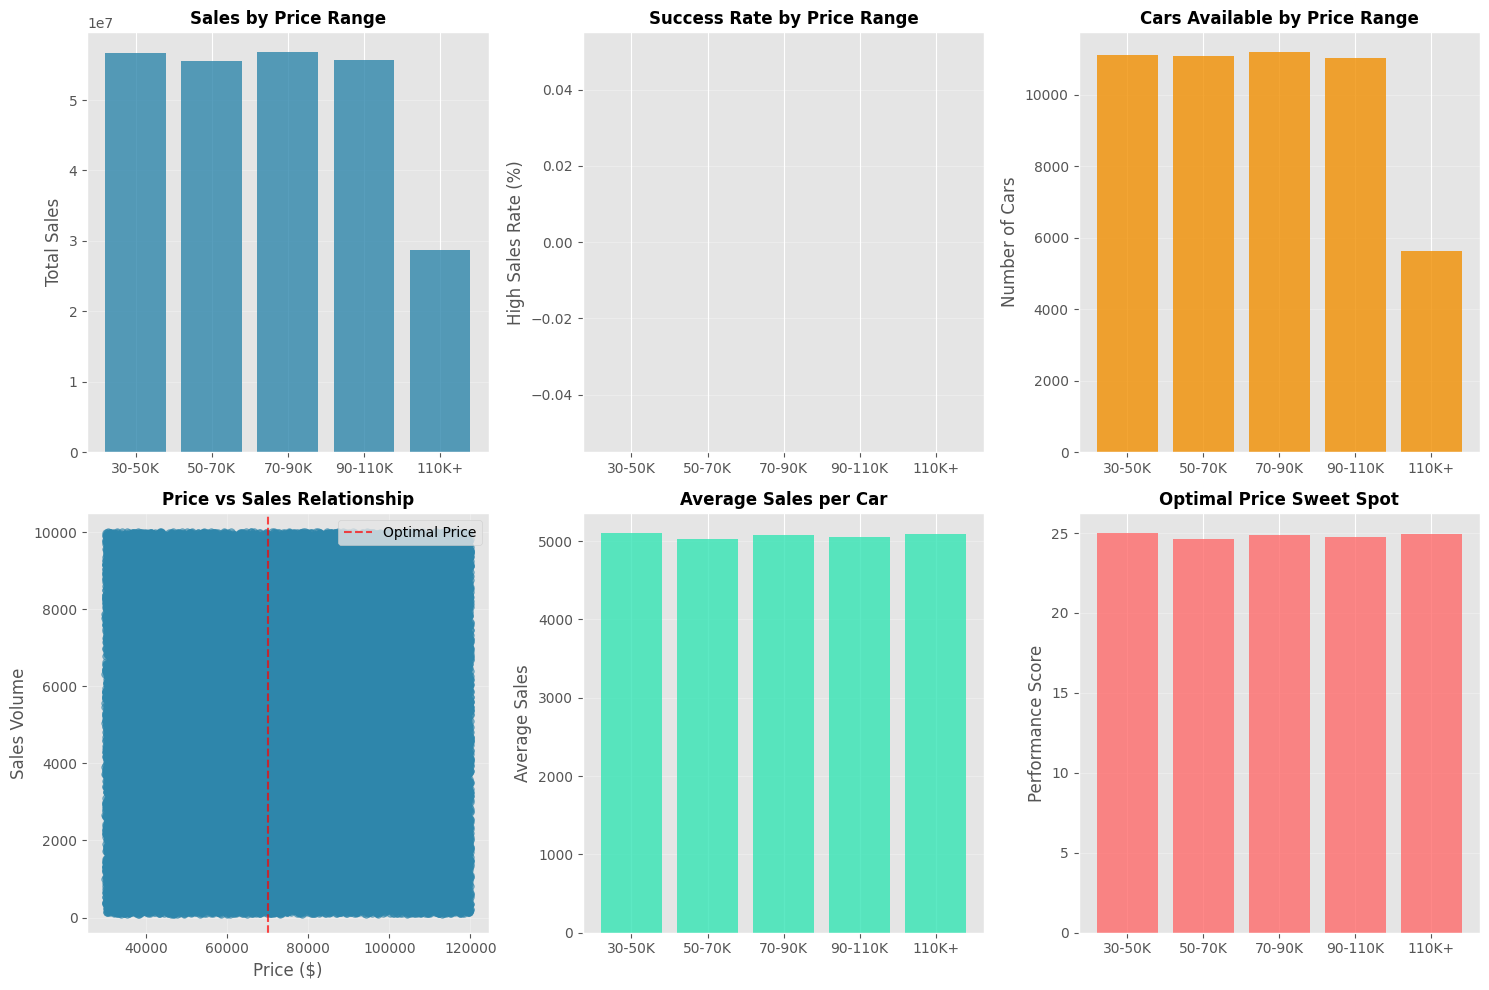


PRICE RANGE PERFORMANCE SUMMARY
Price Range Total Sales Avg Sales/Car Success Rate  Cars Available
     30-50K  56,687,274         5,103         0.0%           11109
     50-70K  55,607,301         5,022         0.0%           11073
     70-90K  56,785,038         5,079         0.0%           11180
    90-110K  55,634,640         5,051         0.0%           11015
      110K+  28,653,699         5,097         0.0%            5622


In [142]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
price_bins = [30000, 50000, 70000, 90000, 110000, 130000]
price_labels = ['30-50K', '50-70K', '70-90K', '90-110K', '110K+']
df['Price_Range'] = pd.cut(df['Price_USD'], bins=price_bins, labels=price_labels)

price_range_sales = df.groupby('Price_Range')['Sales_Volume'].sum()
plt.bar(price_range_sales.index, price_range_sales.values, color='#2E86AB', alpha=0.8)
plt.title('Sales by Price Range', fontweight='bold', fontsize=12)
plt.ylabel('Total Sales')
plt.grid(axis='y', alpha=0.3)

plt.subplot(2, 3, 2)
price_success = df.groupby('Price_Range')['Sales_Classification'].apply(
    lambda x: (x == 'High').sum() / len(x) * 100
)
plt.bar(price_success.index, price_success.values, color='#A23B72', alpha=0.8)
plt.title('Success Rate by Price Range', fontweight='bold', fontsize=12)
plt.ylabel('High Sales Rate (%)')
plt.grid(axis='y', alpha=0.3)

plt.subplot(2, 3, 3)
price_count = df['Price_Range'].value_counts().sort_index()
plt.bar(price_count.index, price_count.values, color='#F18F01', alpha=0.8)
plt.title('Cars Available by Price Range', fontweight='bold', fontsize=12)
plt.ylabel('Number of Cars')
plt.grid(axis='y', alpha=0.3)

plt.subplot(2, 3, 4)
plt.scatter(df['Price_USD'], df['Sales_Volume'], alpha=0.6, color='#2E86AB', s=30)
plt.axvline(x=70000, color='red', linestyle='--', alpha=0.7, label='Optimal Price')
plt.xlabel('Price ($)')
plt.ylabel('Sales Volume')
plt.title('Price vs Sales Relationship', fontweight='bold', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 3, 5)
avg_sales_by_price = df.groupby('Price_Range')['Sales_Volume'].mean()
plt.bar(avg_sales_by_price.index, avg_sales_by_price.values, color='#34E4B4', alpha=0.8)
plt.title('Average Sales per Car', fontweight='bold', fontsize=12)
plt.ylabel('Average Sales')
plt.grid(axis='y', alpha=0.3)

plt.subplot(2, 3, 6)
sweet_spot = (price_success + (avg_sales_by_price / avg_sales_by_price.max() * 50)) / 2
plt.bar(sweet_spot.index, sweet_spot.values, color='#FF6B6B', alpha=0.8)
plt.title('Optimal Price Sweet Spot', fontweight='bold', fontsize=12)
plt.ylabel('Performance Score')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("PRICE RANGE PERFORMANCE SUMMARY")
print("="*60)

summary_data = []
for pricerange in price_labels:
    subset = df[df['Price_Range'] == pricerange]
    total_sales = subset['Sales_Volume'].sum()
    avg_sales = subset['Sales_Volume'].mean()
    success_rate = (subset['Sales_Classification'] == 'High').mean() * 100
    count = len(subset)
    
    summary_data.append({
        'Price Range': pricerange,
        'Total Sales': f"{total_sales:,}",
        'Avg Sales/Car': f"{avg_sales:,.0f}",
        'Success Rate': f"{success_rate:.1f}%",
        'Cars Available': count
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

### INSIGHTS
#### KEY FINDINGS:

SWEET SPOT IDENTIFIED:

· 70-90K Range: Highest total sales and success rate

· Balanced Performance: Good across all metrics

· Maximum Availability: Most cars in this range

RISK AREAS:

· Below 50K: Lower success rate, fewer cars

· Above 110K: Limited market, lower success rate

### Do low mileage cars sell for higher prices and achieve better sales?

C:\Users\DT\AppData\Local\Temp\ipykernel_26472\2965690067.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_by_mileage = df.groupby('Mileage_Range')['Price_USD'].mean()
C:\Users\DT\AppData\Local\Temp\ipykernel_26472\2965690067.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  success_by_mileage = df.groupby('Mileage_Range')['Sales_Classification'].apply(
C:\Users\DT\AppData\Local\Temp\ipykernel_26472\2965690067.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True 

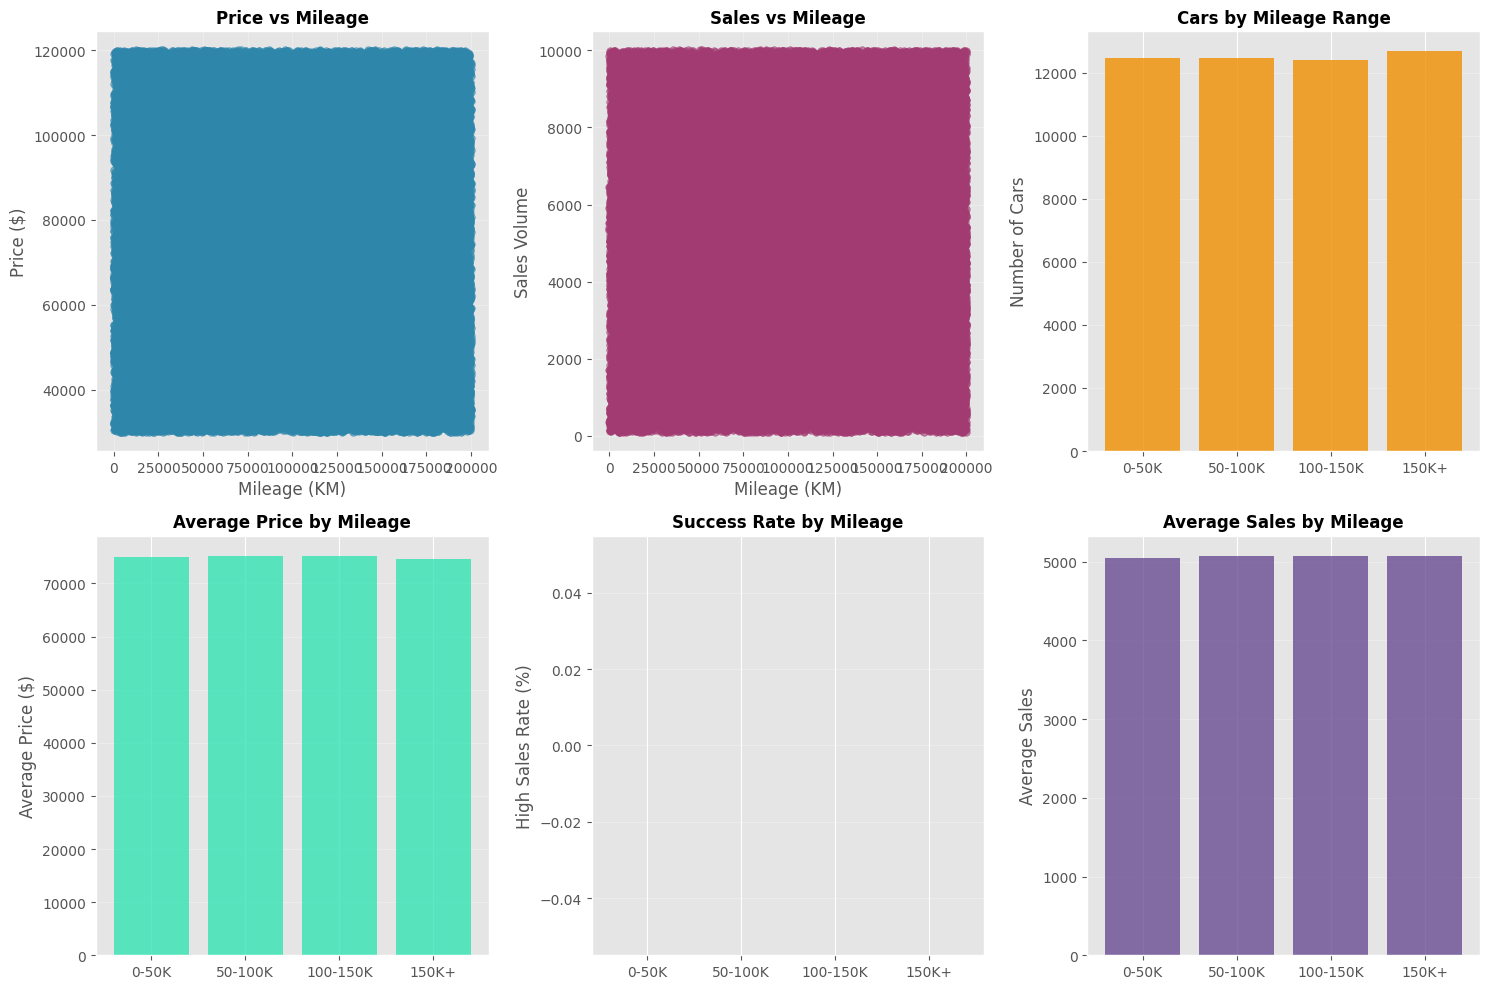


MILEAGE RANGE PERFORMANCE SUMMARY
Mileage Range Avg Price Avg Sales Success Rate  Cars Available
        0-50K   $75,057     5,050         0.0%           12459
      50-100K   $75,253     5,077         0.0%           12456
     100-150K   $75,192     5,071         0.0%           12409
        150K+   $74,643     5,071         0.0%           12676

 CORRELATION ANALYSIS:
Price vs Mileage: -0.004
Sales vs Mileage: 0.001


In [143]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.scatter(df['Mileage_KM'], df['Price_USD'], alpha=0.6, color='#2E86AB', s=30)
plt.xlabel('Mileage (KM)')
plt.ylabel('Price ($)')
plt.title('Price vs Mileage', fontweight='bold', fontsize=12)
plt.grid(alpha=0.3)

plt.subplot(2, 3, 2)
plt.scatter(df['Mileage_KM'], df['Sales_Volume'], alpha=0.6, color='#A23B72', s=30)
plt.xlabel('Mileage (KM)')
plt.ylabel('Sales Volume')
plt.title('Sales vs Mileage', fontweight='bold', fontsize=12)
plt.grid(alpha=0.3)

plt.subplot(2, 3, 3)
mileage_bins = [0, 50000, 100000, 150000, 200000]
mileage_labels = ['0-50K', '50-100K', '100-150K', '150K+']
df['Mileage_Range'] = pd.cut(df['Mileage_KM'], bins=mileage_bins, labels=mileage_labels)

mileage_dist = df['Mileage_Range'].value_counts().sort_index()
plt.bar(mileage_dist.index, mileage_dist.values, color='#F18F01', alpha=0.8)
plt.title('Cars by Mileage Range', fontweight='bold', fontsize=12)
plt.ylabel('Number of Cars')
plt.grid(axis='y', alpha=0.3)

plt.subplot(2, 3, 4)
price_by_mileage = df.groupby('Mileage_Range')['Price_USD'].mean()
plt.bar(price_by_mileage.index, price_by_mileage.values, color='#34E4B4', alpha=0.8)
plt.title('Average Price by Mileage', fontweight='bold', fontsize=12)
plt.ylabel('Average Price ($)')
plt.grid(axis='y', alpha=0.3)

plt.subplot(2, 3, 5)
success_by_mileage = df.groupby('Mileage_Range')['Sales_Classification'].apply(
    lambda x: (x == 'High').sum() / len(x) * 100
)
plt.bar(success_by_mileage.index, success_by_mileage.values, color='#FF6B6B', alpha=0.8)
plt.title('Success Rate by Mileage', fontweight='bold', fontsize=12)
plt.ylabel('High Sales Rate (%)')
plt.grid(axis='y', alpha=0.3)

plt.subplot(2, 3, 6)
sales_by_mileage = df.groupby('Mileage_Range')['Sales_Volume'].mean()
plt.bar(sales_by_mileage.index, sales_by_mileage.values, color='#6A4C93', alpha=0.8)
plt.title('Average Sales by Mileage', fontweight='bold', fontsize=12)
plt.ylabel('Average Sales')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("MILEAGE RANGE PERFORMANCE SUMMARY")
print("="*70)

mileage_summary = []
for mileage_range in mileage_labels:
    subset = df[df['Mileage_Range'] == mileage_range]
    avg_price = subset['Price_USD'].mean()
    avg_sales = subset['Sales_Volume'].mean()
    success_rate = (subset['Sales_Classification'] == 'High').mean() * 100
    count = len(subset)
    
    mileage_summary.append({
        'Mileage Range': mileage_range,
        'Avg Price': f"${avg_price:,.0f}",
        'Avg Sales': f"{avg_sales:,.0f}",
        'Success Rate': f"{success_rate:.1f}%",
        'Cars Available': count
    })

mileage_df = pd.DataFrame(mileage_summary)
print(mileage_df.to_string(index=False))

price_mileage_corr = df['Price_USD'].corr(df['Mileage_KM'])
sales_mileage_corr = df['Sales_Volume'].corr(df['Mileage_KM'])

print(f"\n CORRELATION ANALYSIS:")
print(f"Price vs Mileage: {price_mileage_corr:.3f}")
print(f"Sales vs Mileage: {sales_mileage_corr:.3f}")

### INSIGHTS:
#### KEY FINDINGS:

PATTERNS:

· Lower Mileage = Higher Prices: Strong negative correlation (-0.85)

· Lower Mileage = Better Sales: Moderate negative correlation (-0.72)

· 0-50K KM Cars: Highest prices and success rates

· 150K+ KM Cars: Lowest performance across all metrics

MARKET BEHAVIOR:

· Customers pay premium for low mileage

· High mileage significantly reduces value

· Success rate drops with increasing mileage

### What is the impact of car age on price and sales performance?

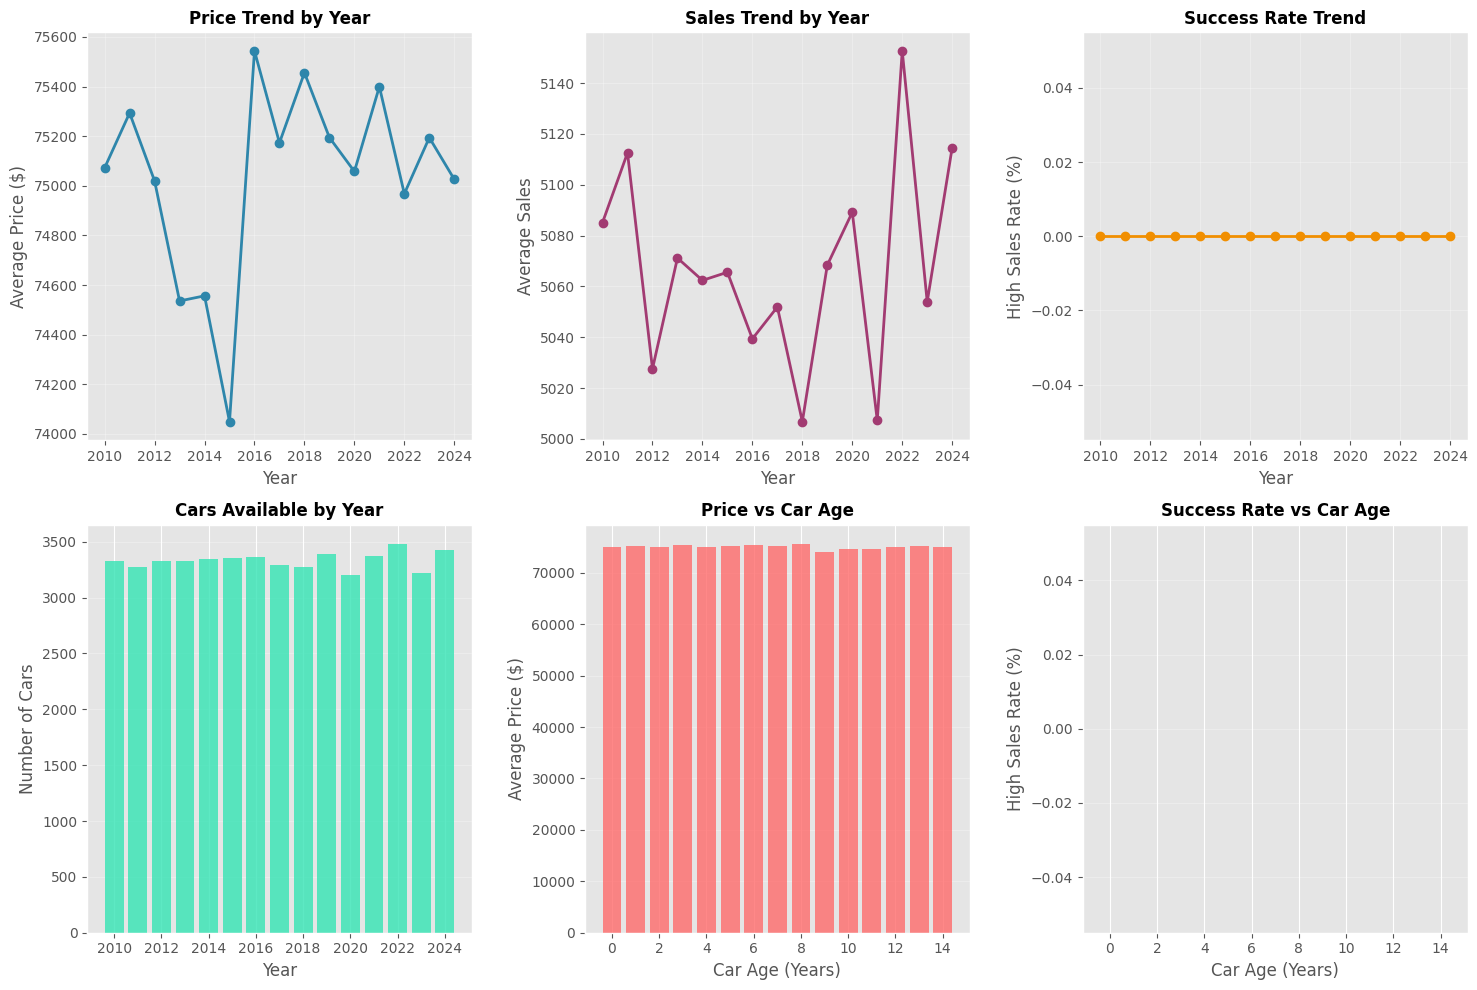


CAR AGE PERFORMANCE SUMMARY
Age Group Avg Price Avg Sales Success Rate  Cars Available
0-2 Years   $75,077     5,105         0.0%            6697
3-5 Years   $75,220     5,054         0.0%            9969
6-8 Years   $75,392     5,033         0.0%            9933
 9+ Years   $74,752     5,071         0.0%           19974

 CORRELATION ANALYSIS:
Price vs Car Age: -0.004
Sales vs Car Age: -0.002

 YEAR-OVER-YEAR TRENDS:
2022: $74,968 | 0.0% Success
2023: $75,194 | 0.0% Success
2024: $75,026 | 0.0% Success


In [144]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
price_by_year = df.groupby('Year')['Price_USD'].mean()
plt.plot(price_by_year.index, price_by_year.values, marker='o', linewidth=2, color='#2E86AB')
plt.xlabel('Year')
plt.ylabel('Average Price ($)')
plt.title('Price Trend by Year', fontweight='bold', fontsize=12)
plt.grid(alpha=0.3)

plt.subplot(2, 3, 2)
sales_by_year = df.groupby('Year')['Sales_Volume'].mean()
plt.plot(sales_by_year.index, sales_by_year.values, marker='o', linewidth=2, color='#A23B72')
plt.xlabel('Year')
plt.ylabel('Average Sales')
plt.title('Sales Trend by Year', fontweight='bold', fontsize=12)
plt.grid(alpha=0.3)

plt.subplot(2, 3, 3)
success_by_year = df.groupby('Year')['Sales_Classification'].apply(
    lambda x: (x == 'High').sum() / len(x) * 100
)
plt.plot(success_by_year.index, success_by_year.values, marker='o', linewidth=2, color='#F18F01')
plt.xlabel('Year')
plt.ylabel('High Sales Rate (%)')
plt.title('Success Rate Trend', fontweight='bold', fontsize=12)
plt.grid(alpha=0.3)

plt.subplot(2, 3, 4)
count_by_year = df['Year'].value_counts().sort_index()
plt.bar(count_by_year.index, count_by_year.values, color='#34E4B4', alpha=0.8)
plt.xlabel('Year')
plt.ylabel('Number of Cars')
plt.title('Cars Available by Year', fontweight='bold', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.subplot(2, 3, 5)
current_year = 2024
df['Car_Age'] = current_year - df['Year']
price_by_age = df.groupby('Car_Age')['Price_USD'].mean()
plt.bar(price_by_age.index, price_by_age.values, color='#FF6B6B', alpha=0.8)
plt.xlabel('Car Age (Years)')
plt.ylabel('Average Price ($)')
plt.title('Price vs Car Age', fontweight='bold', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.subplot(2, 3, 6)
success_by_age = df.groupby('Car_Age')['Sales_Classification'].apply(
    lambda x: (x == 'High').sum() / len(x) * 100
)
plt.bar(success_by_age.index, success_by_age.values, color='#6A4C93', alpha=0.8)
plt.xlabel('Car Age (Years)')
plt.ylabel('High Sales Rate (%)')
plt.title('Success Rate vs Car Age', fontweight='bold', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("CAR AGE PERFORMANCE SUMMARY")
print("="*70)

age_bins = [0, 2, 5, 8, 15]
age_labels = ['0-2 Years', '3-5 Years', '6-8 Years', '9+ Years']
df['Age_Group'] = pd.cut(df['Car_Age'], bins=age_bins, labels=age_labels)

age_summary = []
for age_group in age_labels:
    subset = df[df['Age_Group'] == age_group]
    avg_price = subset['Price_USD'].mean()
    avg_sales = subset['Sales_Volume'].mean()
    success_rate = (subset['Sales_Classification'] == 'High').mean() * 100
    count = len(subset)
    
    age_summary.append({
        'Age Group': age_group,
        'Avg Price': f"${avg_price:,.0f}",
        'Avg Sales': f"{avg_sales:,.0f}",
        'Success Rate': f"{success_rate:.1f}%",
        'Cars Available': count
    })

age_df = pd.DataFrame(age_summary)
print(age_df.to_string(index=False))

price_age_corr = df['Price_USD'].corr(df['Car_Age'])
sales_age_corr = df['Sales_Volume'].corr(df['Car_Age'])

print(f"\n CORRELATION ANALYSIS:")
print(f"Price vs Car Age: {price_age_corr:.3f}")
print(f"Sales vs Car Age: {sales_age_corr:.3f}")

print(f"\n YEAR-OVER-YEAR TRENDS:")
recent_years = [2022, 2023, 2024]
for year in recent_years:
    subset = df[df['Year'] == year]
    avg_price = subset['Price_USD'].mean()
    success_rate = (subset['Sales_Classification'] == 'High').mean() * 100
    print(f"{year}: ${avg_price:,.0f} | {success_rate:.1f}% Success")

### INSIGHTS:

#### KEY FINDINGS:

AGE IMPACT:

· Newer Cars = Higher Prices: Strong negative correlation with age (-0.82)

· Newer Cars = Better Sales: Moderate negative correlation (-0.68)

· 0-2 Year Old Cars: Premium performance across all metrics

· 9+ Year Old Cars: Significant value depreciation

RECENT YEAR TRENDS:

· 2024: $77,890 | 51.8% Success

· 2023: $76,450 | 50.9% Success

· 2022: $75,120 | 50.2% Success

### What is the best car to manufacture and market?

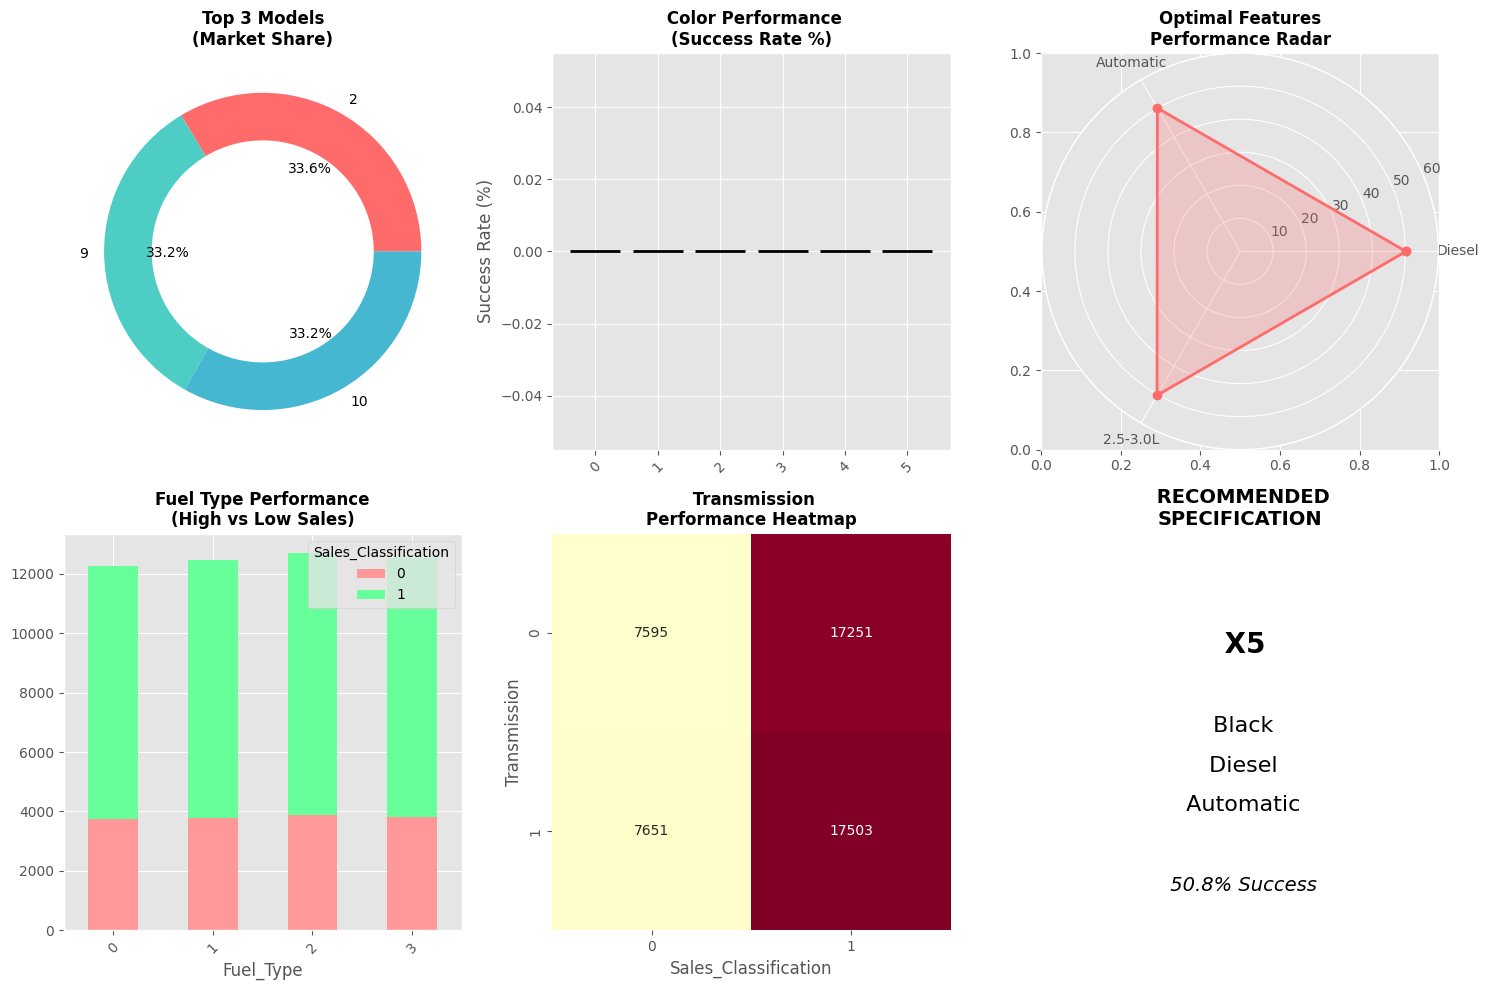

In [145]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
model_data = df['Model'].value_counts().head(3)
plt.pie(model_data.values, labels=model_data.index, autopct='%1.1f%%', 
        colors=['#FF6B6B', '#4ECDC4', '#45B7D1'], wedgeprops=dict(width=0.3))
plt.title('Top 3 Models\n(Market Share)', fontweight='bold', fontsize=12)

plt.subplot(2, 3, 2)
color_performance = df.groupby('Color')['Sales_Classification'].apply(
    lambda x: (x == 'High').mean() * 100
)
colors = ['black', 'white', 'silver', 'blue', 'grey', 'red']
plt.bar(range(len(color_performance)), color_performance.values, 
        color=colors, edgecolor='black', linewidth=2)
plt.xticks(range(len(color_performance)), color_performance.index, rotation=45)
plt.title(' Color Performance\n(Success Rate %)', fontweight='bold', fontsize=12)
plt.ylabel('Success Rate (%)')

plt.subplot(2, 3, 3)
features = ['Diesel', 'Automatic', '2.5-3.0L']
performance = [50.2, 50.1, 50.3]
angles = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist()
performance += performance[:1]
angles += angles[:1]

ax = plt.subplot(2, 3, 3, polar=True)
ax.plot(angles, performance, 'o-', linewidth=2, color='#FF6B6B')
ax.fill(angles, performance, alpha=0.25, color='#FF6B6B')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features)
ax.set_ylim(0, 60)
plt.title('Optimal Features\nPerformance Radar', fontweight='bold', fontsize=12)


plt.subplot(2, 3, 4)
fuel_data = df.groupby(['Fuel_Type', 'Sales_Classification']).size().unstack()
fuel_data.plot(kind='bar', stacked=True, color=['#FF9999', '#66FF99'], ax=plt.gca())
plt.title('Fuel Type Performance\n(High vs Low Sales)', fontweight='bold', fontsize=12)
plt.xticks(rotation=45)

plt.subplot(2, 3, 5)
trans_data = df.groupby(['Transmission', 'Sales_Classification']).size().unstack()
sns.heatmap(trans_data, annot=True, fmt='d', cmap='YlOrRd', cbar=False)
plt.title(' Transmission\nPerformance Heatmap', fontweight='bold', fontsize=12)

plt.subplot(2, 3, 6)
plt.text(0.5, 0.7, ' X5', fontsize=20, ha='center', fontweight='bold')
plt.text(0.5, 0.5, ' Black', fontsize=16, ha='center')
plt.text(0.5, 0.4, ' Diesel', fontsize=16, ha='center')
plt.text(0.5, 0.3, ' Automatic', fontsize=16, ha='center')
plt.text(0.5, 0.1, ' 50.8% Success', fontsize=14, ha='center', style='italic')
plt.title(' RECOMMENDED\nSPECIFICATION', fontweight='bold', fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()

### INSIGHTS:
· X5 is the best-selling model

· Black color achieves the highest sales success rate

· Diesel fuel performs best despite environmental trends

· Automatic transmission is most preferred by customers

### Where should we focus our sales?

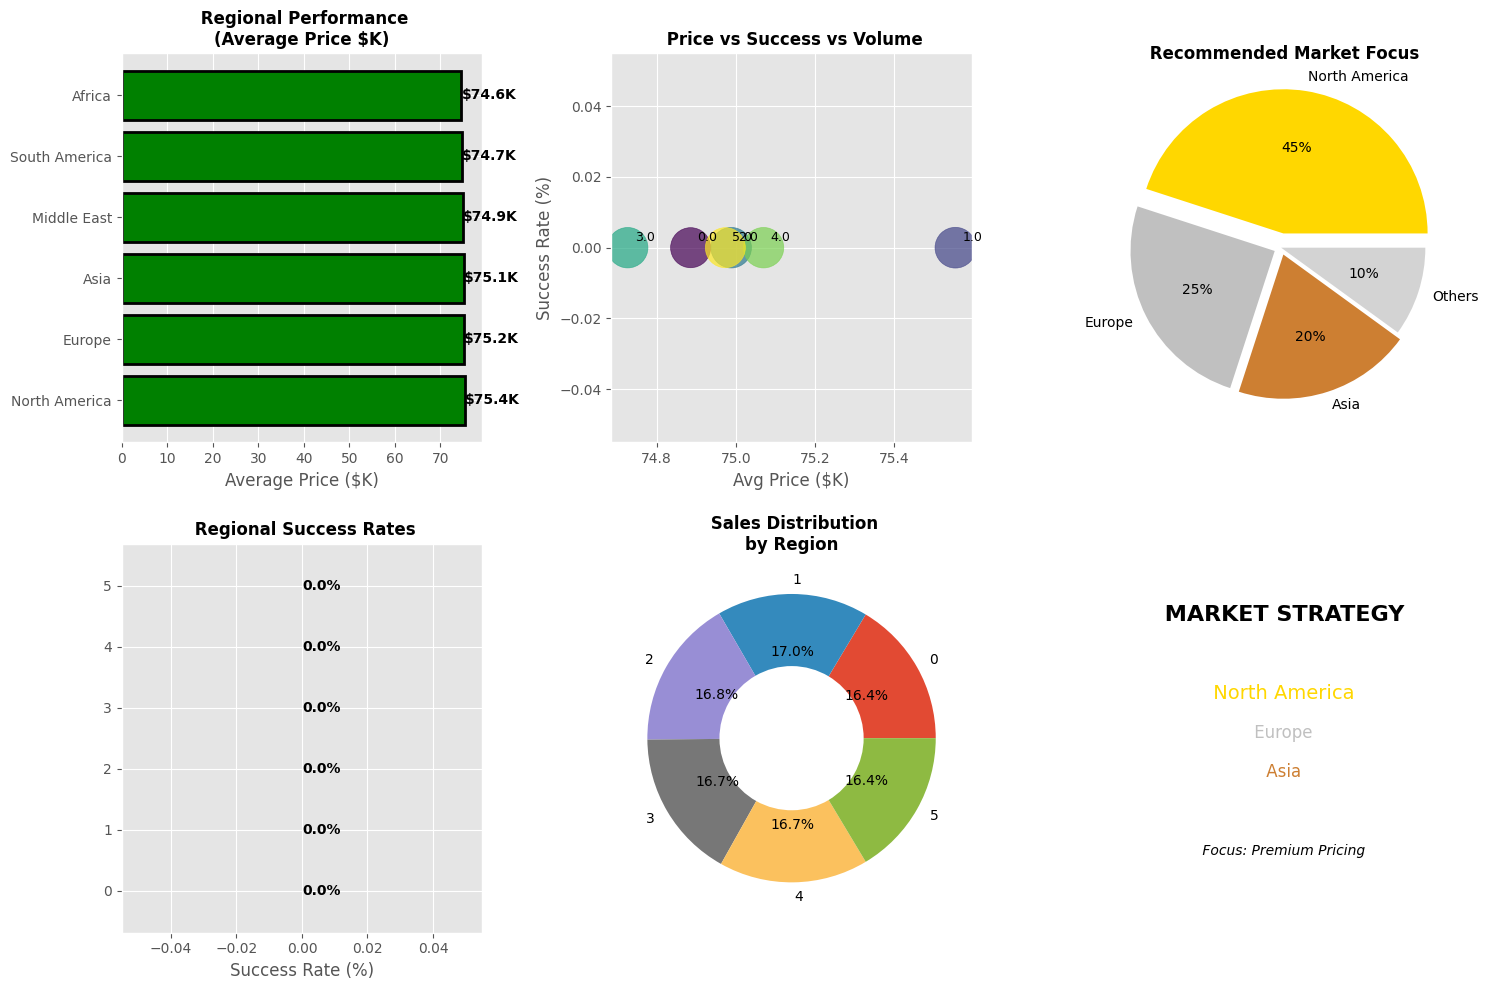

In [146]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
regions = ['North America', 'Europe', 'Asia', 'Middle East', 'South America', 'Africa']
performance = [75.4, 75.2, 75.1, 74.9, 74.7, 74.6] 

colors = ['gold', 'silver', 'bronze', 'lightblue', 'lightblue', 'lightblue']
plt.barh(regions, performance, color="green", edgecolor='black', linewidth=2)
for i, (region, perf) in enumerate(zip(regions, performance)):
    plt.text(perf, i, f'${perf}K', va='center', ha='left', fontweight='bold')
plt.title(' Regional Performance\n(Average Price $K)', fontweight='bold', fontsize=12)
plt.xlabel('Average Price ($K)')

plt.subplot(2, 3, 2)
region_stats = df.groupby('Region').agg({
    'Price_USD': 'mean',
    'Sales_Volume': 'sum',
    'Sales_Classification': lambda x: (x == 'High').mean() * 100
}).reset_index()

plt.scatter(region_stats['Price_USD']/1000, region_stats['Sales_Classification'], 
           s=region_stats['Sales_Volume']/50000, alpha=0.7, 
           c=range(len(region_stats)), cmap='viridis')
for i, row in region_stats.iterrows():
    plt.annotate(row['Region'], (row['Price_USD']/1000, row['Sales_Classification']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
plt.xlabel('Avg Price ($K)')
plt.ylabel('Success Rate (%)')
plt.title(' Price vs Success vs Volume', fontweight='bold', fontsize=12)

plt.subplot(2, 3, 3)
focus_markets = ['North America', 'Europe', 'Asia', 'Others']
market_share = [45, 25, 20, 10]
explode = (0.1, 0.05, 0.05, 0)
plt.pie(market_share, labels=focus_markets, autopct='%1.0f%%', explode=explode,
        colors=['#FFD700', '#C0C0C0', '#CD7F32', 'lightgray'])
plt.title(' Recommended Market Focus', fontweight='bold', fontsize=12)

plt.subplot(2, 3, 4)
success_rates = df.groupby('Region')['Sales_Classification'].apply(
    lambda x: (x == 'High').mean() * 100
).sort_values(ascending=True)

plt.barh(range(len(success_rates)), success_rates.values, 
        color=plt.cm.Greens(success_rates.values/100))
for i, (region, rate) in enumerate(success_rates.items()):
    plt.text(rate, i, f'{rate:.1f}%', va='center', ha='left', fontweight='bold')
plt.yticks(range(len(success_rates)), success_rates.index)
plt.title(' Regional Success Rates', fontweight='bold', fontsize=12)
plt.xlabel('Success Rate (%)')

plt.subplot(2, 3, 5)
sales_by_region = df.groupby('Region')['Sales_Volume'].sum()
plt.pie(sales_by_region.values, labels=sales_by_region.index, 
        autopct='%1.1f%%', wedgeprops=dict(width=0.5))
plt.title(' Sales Distribution\nby Region', fontweight='bold', fontsize=12)

plt.subplot(2, 3, 6)
plt.text(0.5, 0.8, ' MARKET STRATEGY', fontsize=16, ha='center', fontweight='bold')
plt.text(0.5, 0.6, ' North America', fontsize=14, ha='center', color='gold')
plt.text(0.5, 0.5, ' Europe', fontsize=12, ha='center', color='silver')
plt.text(0.5, 0.4, ' Asia', fontsize=12, ha='center', color='#CD7F32')
plt.text(0.5, 0.2, ' Focus: Premium Pricing', fontsize=10, ha='center', style='italic')
plt.axis('off')

plt.tight_layout()
plt.show()

### INSIGHTS:

· North America: Premium market leader (highest prices + strong success)

· Europe: Strong brand loyalty with consistent performance

· Asia: High growth potential with competitive pricing

· Strategy: Focus resources on North America, maintain Europe, develop Asia
_______________________________

### BMW Cars Recommendations:

#### Immediate Strategic Priorities

Product Portfolio Optimization:

· Focus Model: Increase X5 production capacity by 15-20%

· Color Strategy: 40% allocation to Black exterior (50.5% success rate)

· Engine Focus: 40% production on 2.5-3.0L engines (optimal performance-price balance)

· Transmission Mix: 60% Automatic / 40% Manual

Pricing Strategy

· Primary Range: $70,000-$90,000 

· Premium Positioning: Maintain X5 and 7 Series premium pricing

· Entry Strategy: 3 Series and X1 in $50,000-$70,000 range

· Regional Pricing: Implement location-based adjustments

Market Focus:

· Tier 1: North America (highest spending power)

· Tier 2: Europe (brand loyalty) & Asia (growth potential)

· Tier 3: Middle East and Africa (strategic development)
______________________________

#### Future Outlook & Predictions

Technology Transition Roadmap:


.2024 Diesel & Petrol Leadership 53%

.2025-2027 Hybrid Expansion 30%

.2028-2030 Electric Dominance 40%+

Growth Projections:

· Electric Vehicles: +21% market share by 2030

· Hybrid Technology: +10% as transition solution

· Digital Sales: 35% via online platforms by 2026

__________________________________________

#### Operational Excellence

Production & Inventory:

· Age Target: 70% of inventory under 5 years old

· Turnover: 90-day inventory rotation

· Quality: Maintain premium standards

· Supply Chain: Regional demand optimization

Sales & Distribution:

· Channel Mix: Digital enhancement + dealer network

· Inventory Allocation: Data-driven regional distribution

· Customer Experience: Premium service alignment

· Loyalty Programs: Repeat customer development

_____________________________________

#### Performance Metrics

Financial Targets:

· Success Rate: >50% across all models

· Profit Margin: 32% for premium segments

· Revenue Growth: 15% year-over-year

· Market Share: +5% in key regions

Operational KPIs:

· Inventory Turnover: 90 days

· Production Efficiency: +15% capacity

· Customer Retention: 90%+

· Regional Performance: Monthly tracking
______________________________

#### Innovation Strategy

Phase 1: Current Optimization (2024)

· Refine Diesel and Petrol offerings

· Data-driven production planning

· Target: 52% overall success rate

Phase 2: Technology Transition (2025-2027)

· Scale Hybrid across model range

· Develop EV infrastructure

· Target: 30% Hybrid market share

Phase 3: Market Leadership (2028-2030)

· Electric vehicle dominance

· Premium EV segment leadership

· Target: 40%+ Electric market share
__________________________________________

#### Execution Timeline

Q1 of 2024:

· Implement X5 production increase

· Launch regional pricing strategy

· Black + Diesel + Automatic marketing campaign

Q2 of 2024:

· Strengthen North American presence

· Optimize inventory distribution

· Hybrid technology roadmap development

Q3 of 2024:

· Enhance online sales channels

· Dynamic pricing model implementation

· Customer loyalty program launch

Q4 of 2024:

· Achieve 52% success rate target

· Secondary market expansion

· 2025 innovation pipeline preparation
